In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import math
import mpmath as mp

# Code to calculate the mean of the Sackin index

In [2]:
# Reference formulas (Yule, uniform, max, min)

# Yule mean
def sackin_yule(n):
    return 2 * n * np.sum(1 / np.arange(2, n + 1))

# Maximum value
def max_sackin(n):
    return (n * (n + 1)) / 2 - 1

# Minimum value
def min_sackin(n):
    return math.floor(np.log2(n) - 1)*n + 3*n - 2**(math.floor(np.log2(n) - 1) + 2)


# Uniform model
def sackin_uniform(n):
    return n * (np.prod(np.arange(2*n - 2, 1, -2) / np.arange(2*n - 3, 0, -2)) - 1)

In [3]:
# Calculating the mean of the Sackin index under the biased speciation model using high-precision arithmetic
# Default precision: max(40, n/2) digits (we found it to be stable for n up to about 10000)

# Returns the ej probabilities for constant p model as an array of length n-2
def constant_p_ej_stable(n, p):
    mp.mp.dps = max(40, n // 2)  # set decimal places
    return [mp.mpf(mp.mpf(p)**j + (mp.mpf(1 - p))**j - 1) for j in range(2, n-1)]

# Return the k-th moment of beta(a,b) distribution with high-precision arithmetic
def beta_moment_stable(a, b, k, digits):
    mp.mp.dps = digits
    return mp.gamma(mp.mpf(a) + k) * mp.gamma(mp.mpf(a) + mp.mpf(b)) / (mp.gamma(mp.mpf(a)) * mp.gamma(mp.mpf(a) + mp.mpf(b) + k))

# Return the ej probabilities for beta(a,b) model as an array of length n-2
def beta_ej_stable(n, a, b):
    mp.mp.dps = max(40, n // 2)  # set decimal places

    ej = []
    for k in range(2, n-1):
        beta_moment_a = beta_moment_stable(a, b, k, mp.mp.dps)
        beta_moment_b = beta_moment_stable(b, a, k, mp.mp.dps)
        ej.append(beta_moment_a + beta_moment_b - mp.mpf(1))
    return ej

# Sum method with high-precision arithmetic
def sackin_mean_sum_stable(n, ej):
    # Corner case: n < 3
    if n < 3:
        return max_sackin(n)
    
    mp.mp.dps = max(40, n//2) # set decimal places
    
    total = mp.mpf((n*(n+1)) / 2 - 1)
    current = mp.mpf((n - 1) * (n - 2) / 2)
    for k in range(3, n):
        current *= mp.mpf(ej[k - 3]) * mp.mpf(int(n - k)) / mp.mpf(k)
        total += current
    return total

# Constant p mean
def sackin_mean_const_p(n, p):
    return sackin_mean_sum_stable(n, constant_p_ej_stable(n, p))

# Beta mean
def sackin_mean_beta(n, a, b):
    return sackin_mean_sum_stable(n, beta_ej_stable(n, a, b))


# Plotting the results

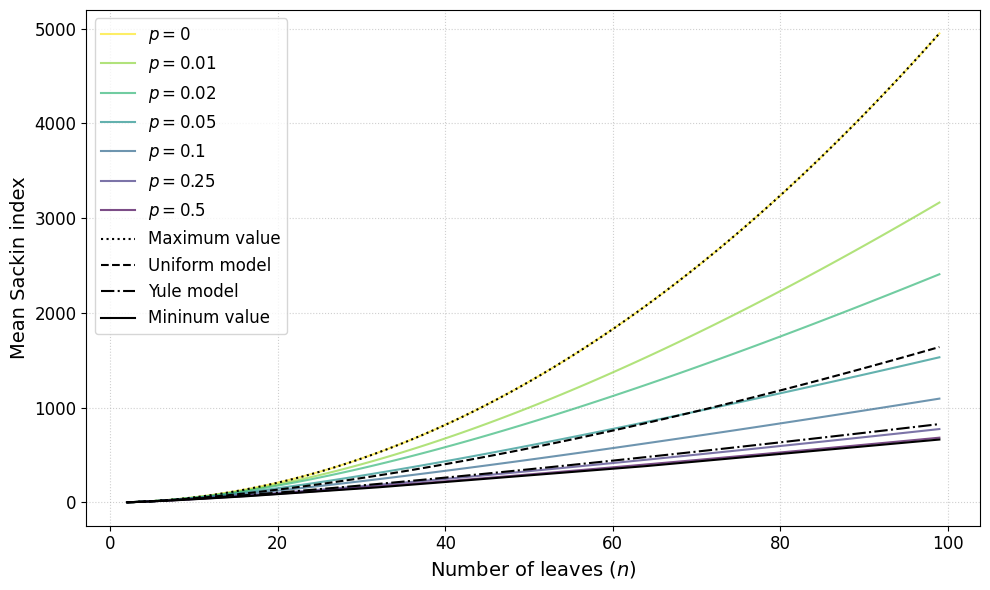

In [149]:
plt.figure(figsize=(10, 6))

# Data range
N = range(2, 100)




# Values of p to plot
p = [0, 0.01, 0.02, 0.05, 0.1, 0.25, 0.5]

# Use a colormap for probabilities
# what is best colormap? 
colors = cm.viridis(np.linspace(1, 0, len(p)))

for prob, color in zip(p, colors):
    means = [sackin_mean_const_p(n, prob) for n in N]
    plt.plot(N, means, label=f"$p={prob}$", alpha=0.7, color=color, lw=1.5)

# Add reference models
plt.plot(N, [max_sackin(n) for n in N], 
         label="Maximum value", linestyle=':', color='black', linewidth=1.5)
plt.plot(N, [sackin_uniform(n) for n in N], 
         label="Uniform model", linestyle='--', color='black', linewidth=1.5)
plt.plot(N, [sackin_yule(n) for n in N], 
         label="Yule model", linestyle='-.', color='black', linewidth=1.5)
plt.plot(N, [min_sackin(n) for n in N], 
         label="Mininum value", linestyle='-', color='black', linewidth=1.5)

# Labels and title
plt.xlabel("Number of leaves ($n$)", fontsize=14)
plt.ylabel("Mean Sackin index", fontsize=14)
# plt.title(r"Mean Sackin index under biased speciation model with split distribution $\lambda \sim p$", fontsize=16)

# Fontsize of axis ticks
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)


# Legend only for reference lines
plt.legend(fontsize=12, loc="upper left")

# Grid and layout
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()

# Save and show
plt.savefig("./plots/sackin_biased_speciation_constant_p.png", dpi=300)
plt.show()

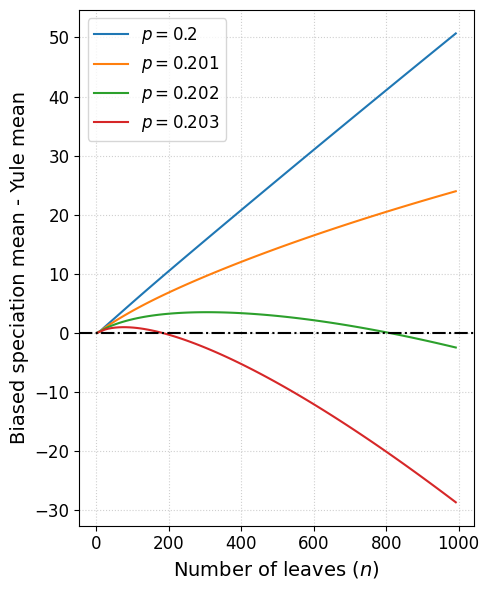

In [150]:
# Comparing the p=0.2 case to Yule
N = np.arange(2, 1000, 10)
plt.figure(figsize=(5, 6))
s = [0.2, 0.201, 0.202, 0.203]

for si in s:
    diff = [sackin_mean_const_p(n, si) - sackin_yule(n) for n in N]
    plt.plot(N, diff, label=f"$p={si}$")
plt.axhline(0, color='black', linestyle='-.')
plt.xlabel("Number of leaves ($n$)", fontsize=14)
plt.ylabel("Biased speciation mean - Yule mean", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)

# Grid and layout
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()

plt.savefig("./plots/sackin_biased_speciation_constant_p_0.2_difference_yule.png", dpi=300)
plt.show()

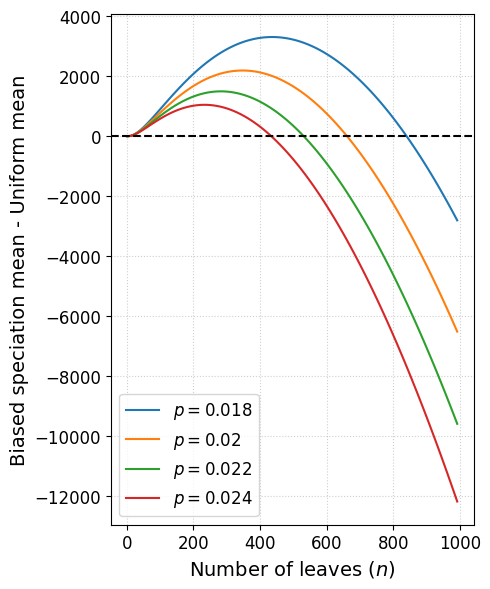

In [151]:
# Do same for Uniform model
plt.figure(figsize=(5, 6))

s = [0.018, 0.02, 0.022, 0.024]

for s1 in s:
    diff = [sackin_mean_const_p(n, s1) - sackin_uniform(n) for n in N]
    plt.plot(N, diff, label=f"$p={s1}$")
plt.axhline(0, color='black', linestyle='dashed')
plt.xlabel("Number of leaves ($n$)", fontsize=14)
plt.ylabel("Biased speciation mean - Uniform mean", fontsize=14)
plt.legend(fontsize=12)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.savefig("./plots/sackin_biased_speciation_constant_p_0.02_difference_uniform.png", dpi=300)
plt.show()

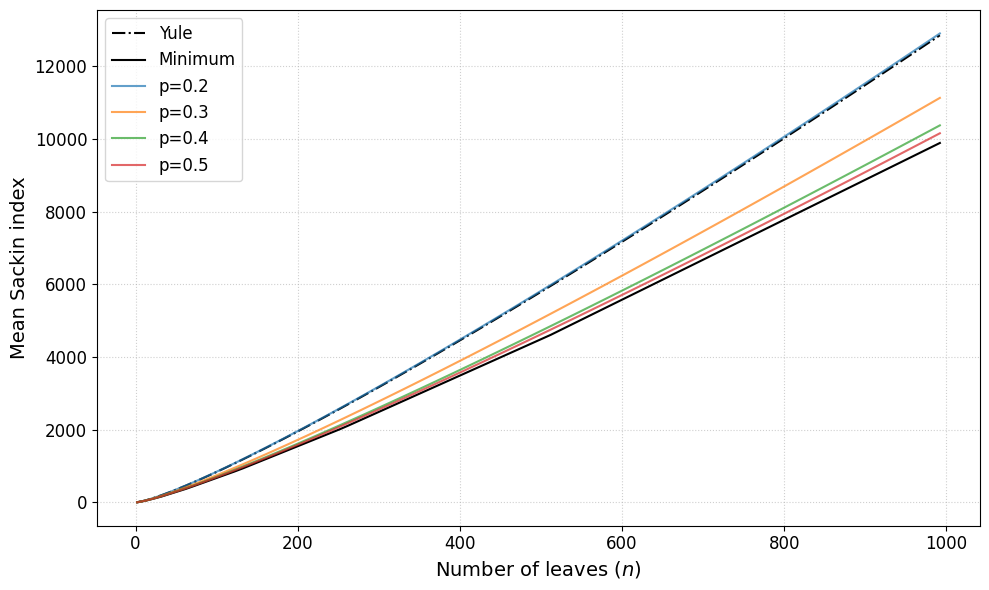

In [152]:
# N = [2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192]

yule = [sackin_yule(n) for n in N]
# p05 = [sackin_mean_const_p(n, 0.5) for n in N]
minimum = [min_sackin(n) for n in N]

plt.figure(figsize=(10, 6))
plt.plot(N, yule, label="Yule", linestyle='-.', color='black')  
plt.plot(N, minimum, label="Minimum", linestyle='-', color='black')

p = [0.2, 0.3, 0.4, 0.5]
for prob in p:
     means = [sackin_mean_const_p(n, prob) for n in N]
     plt.plot(N, means, label=f"p={prob}", linestyle='-', alpha=0.7)
plt.xlabel("Number of leaves ($n$)", fontsize=14)
plt.ylabel("Mean Sackin index", fontsize=14)
# plt.title("Mean Sackin index under biased speciation models with split distribution $\lambda \sim p$", fontsize=16)
plt.legend(fontsize=12)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Grid and layout
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()

plt.savefig("./plots/sackin_biased_speciation_constant_p_large_n.png", dpi=300)
plt.show()

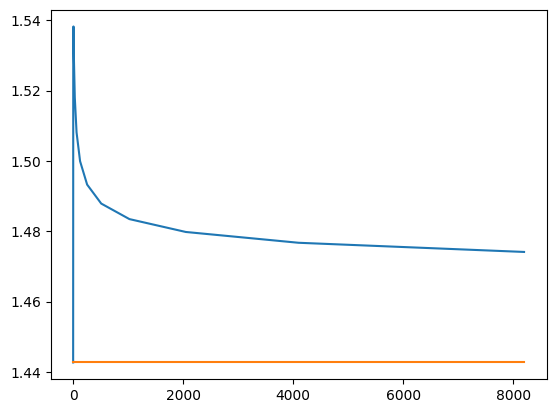

In [89]:
vals = np.array(p05)

plt.plot(N, vals/ np.log(np.array(N)) / np.array(N))
plt.plot(N, minimum/ np.log(np.array(N)) / np.array(N))

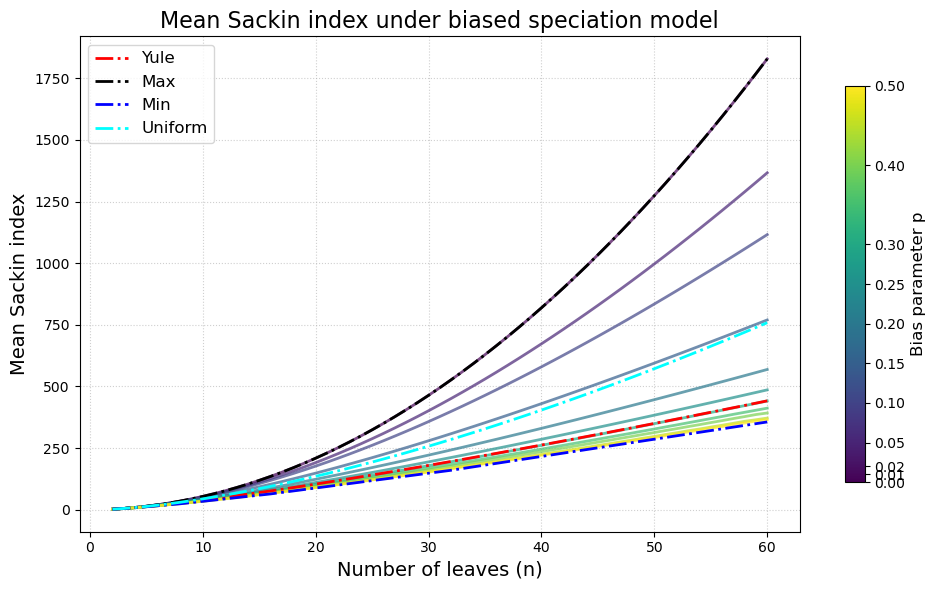

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

plt.figure(figsize=(10, 6))

p = [0, 0.01, 0.02, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5]
N = np.arange(2, 61)

# Use a colormap for probabilities
colors = cm.viridis(np.linspace(0, 1, len(p)))

for prob, color in zip(p, colors):
    means = [sackin_mean_const_p(n, prob) for n in N]
    plt.plot(N, means, color=color, alpha=0.7, lw=2)

# Add reference models
plt.plot(N, [sackin_yule(n) for n in N], 
         label="Yule", linestyle='-.', color='red', linewidth=2)
plt.plot(N, [max_sackin(n) for n in N], 
         label="Max", linestyle='-.', color='black', linewidth=2)
plt.plot(N, [min_sackin(n) for n in N], 
         label="Min", linestyle='-.', color='blue', linewidth=2)
plt.plot(N, [sackin_uniform(n) for n in N], 
         label="Uniform", linestyle='-.', color='aqua', linewidth=2)

# Labels and title
plt.xlabel("Number of leaves (n)", fontsize=14)
plt.ylabel("Mean Sackin index", fontsize=14)
plt.title("Mean Sackin index under biased speciation model", fontsize=16)

# Colorbar for p values
sm = cm.ScalarMappable(cmap=cm.viridis, 
                       norm=plt.Normalize(vmin=min(p), vmax=max(p)))
sm.set_array([])
cbar = plt.colorbar(sm, ticks=p, shrink=0.8, ax=plt.gca())
cbar.set_label("Bias parameter p", fontsize=12)

# Legend only for reference lines
plt.legend(fontsize=12, loc="upper left")

# Grid and layout
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

<>:17: SyntaxWarning: invalid escape sequence '\l'
<>:17: SyntaxWarning: invalid escape sequence '\l'
C:\Users\djbauman\AppData\Local\Temp\ipykernel_296\2033255997.py:17: SyntaxWarning: invalid escape sequence '\l'
  plt.title(f"Mean Sackin index under biased speciation model with $\lambda \sim p$, $n={n}$ ", fontsize=16)


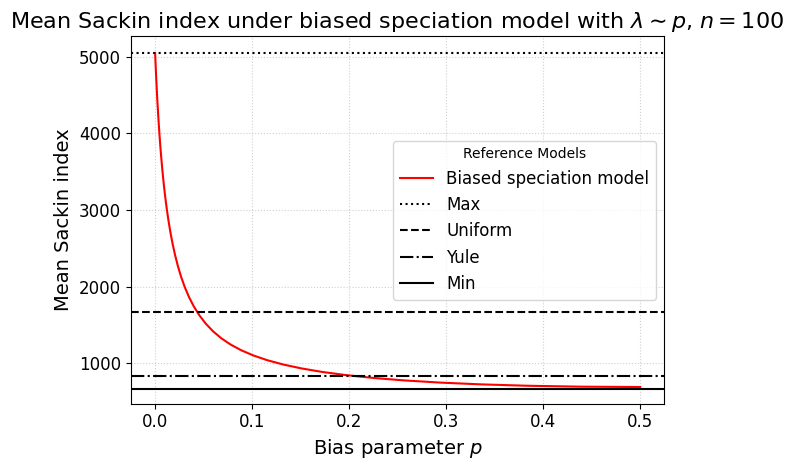

In [39]:
# Fix n, find mean for a range of p
p = np.logspace(-20, -1, 100, base=2)

n = 100
plt.plot(p, [sackin_mean_const_p(n, prob) for prob in p], color = 'red', label='Biased speciation model')

# Add horizontal lines for reference models
plt.axhline(max_sackin(n), color='black', linestyle=':', label="Max")
plt.axhline(sackin_uniform(n), color='black', linestyle='--', label="Uniform")
plt.axhline(sackin_yule(n), color='black', linestyle='-.', label="Yule")
plt.axhline(min_sackin(n), color='black', linestyle='-', label="Min")

plt.xlabel("Bias parameter $p$", fontsize=14)
plt.ylabel("Mean Sackin index", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title(f"Mean Sackin index under biased speciation model with $\lambda \sim p$, $n={n}$ ", fontsize=16)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(title="Reference Models", fontsize=12)

plt.tight_layout()
plt.show()

In [45]:
plt.rcParams['text.usetex'] = False

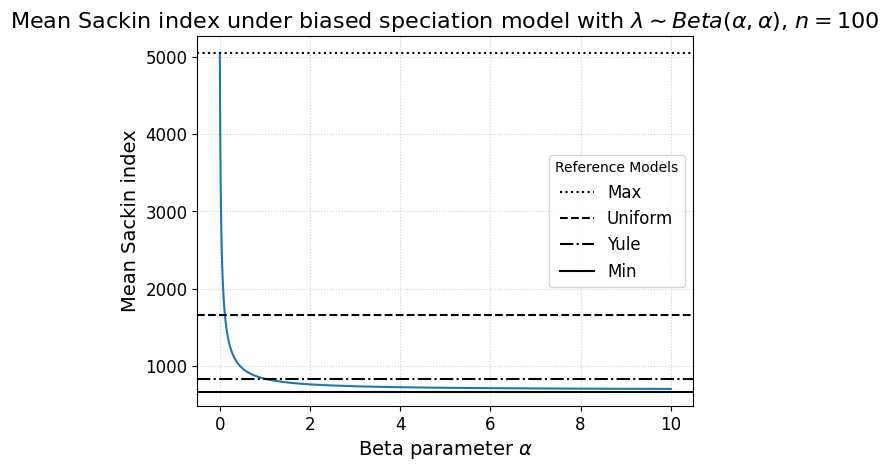

In [51]:
# Do same with beta(1, b) model

a = np.logspace(-5, 1, 100, base=10)

n = 100
plt.plot(a, [sackin_mean_beta(n, ai, ai) for ai in a])

# Add horizontal lines for reference models
plt.axhline(max_sackin(n), color='black', linestyle=':', label="Max")
plt.axhline(sackin_uniform(n), color='black', linestyle='--', label="Uniform")
plt.axhline(sackin_yule(n), color='black', linestyle='-.', label="Yule")
plt.axhline(min_sackin(n), color='black', linestyle='-', label="Min")



plt.xlabel(r"Beta parameter $\alpha$", fontsize=14)
plt.ylabel("Mean Sackin index", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title(rf"Mean Sackin index under biased speciation model with $\lambda \sim Beta(\alpha, \alpha)$, $n={n}$ ", fontsize=16)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(title="Reference Models", fontsize=12)
plt.show()

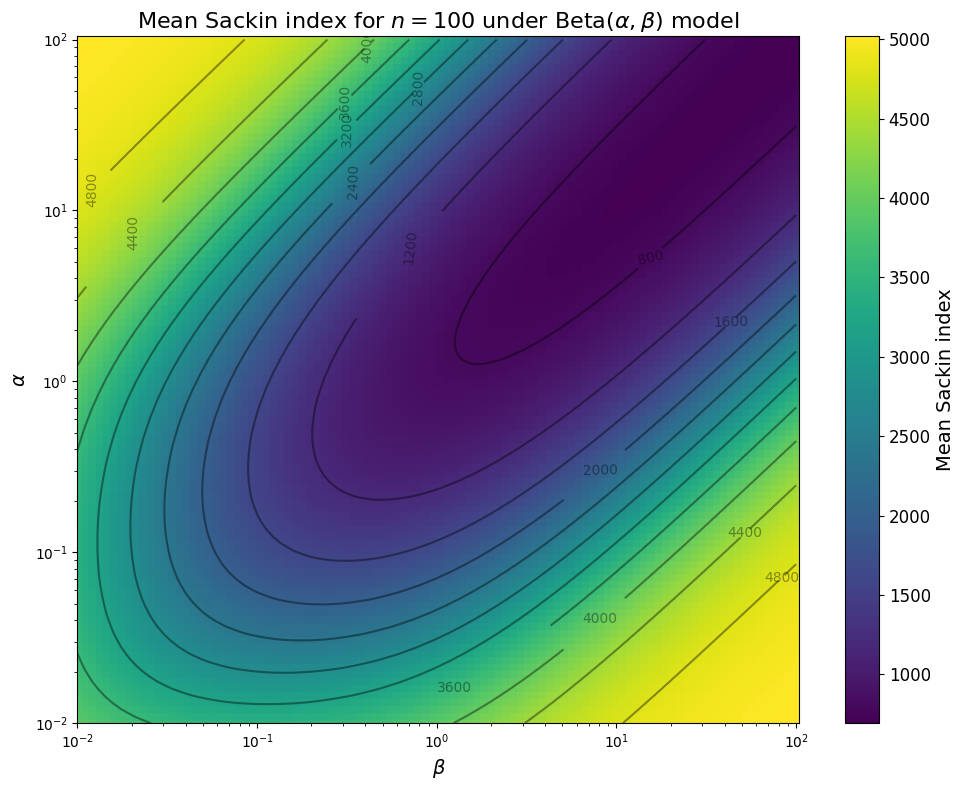

In [105]:
a = np.logspace(-2, 2, 100)
b = a
n = 100

mean_sackin = np.zeros((len(a), len(b)))
for i, ai in enumerate(a):
    for j, bi in enumerate(b):
        mean_sackin[i, j] = sackin_mean_beta(n, ai, bi)

plt.figure(figsize=(10, 8))
mesh = plt.pcolormesh(b, a, mean_sackin, shading='auto', cmap='viridis')

# Add contour lines (on top)
contours = plt.contour(b, a, mean_sackin, colors='k', alpha=0.4, levels=10)

plt.clabel(contours, inline=True, fontsize=10, fmt='%.0f')  # label lines with values

# Colorbar
cbar = plt.colorbar(mesh)
cbar.ax.tick_params(labelsize=12)
cbar.set_label('Mean Sackin index', fontsize=14)

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\beta$', fontsize=14)
plt.ylabel(r'$\alpha$', fontsize=14)
plt.title(rf'Mean Sackin index for $n={n}$ under Beta($\alpha, \beta$) model', fontsize=16)

plt.tight_layout()
plt.show()


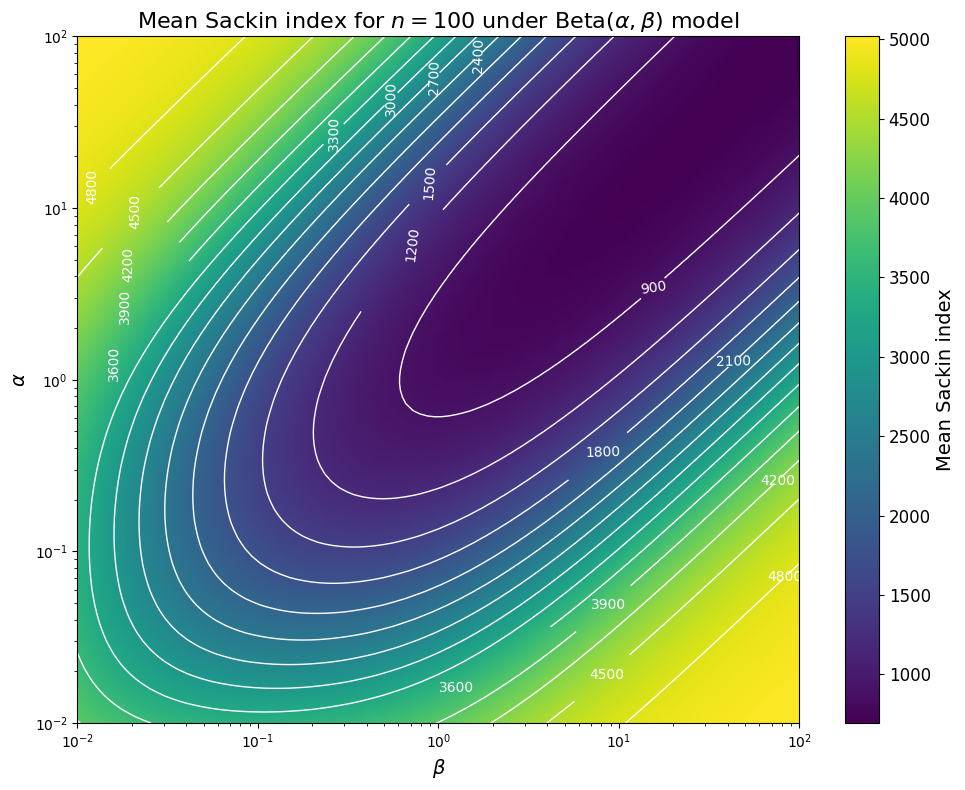

In [114]:
plt.figure(figsize=(10, 8))
mesh = plt.pcolormesh(b, a, mean_sackin, shading='gouraud', cmap='viridis')

# Add contour lines (on top)
contours = plt.contour(b, a, mean_sackin, 
                       colors='white', linewidths=1,
                       levels=15)  # 10 contour levels automatically chosen
plt.clabel(contours, inline=True, fontsize=10, fmt='%.0f')  # label lines with values
# Colorbar
cbar = plt.colorbar(mesh)
cbar.ax.tick_params(labelsize=12)
cbar.set_label('Mean Sackin index', fontsize=14)

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\beta$', fontsize=14)
plt.ylabel(r'$\alpha$', fontsize=14)
plt.title(rf'Mean Sackin index for $n={n}$ under Beta($\alpha, \beta$) model', fontsize=16)

plt.tight_layout()
plt.show()


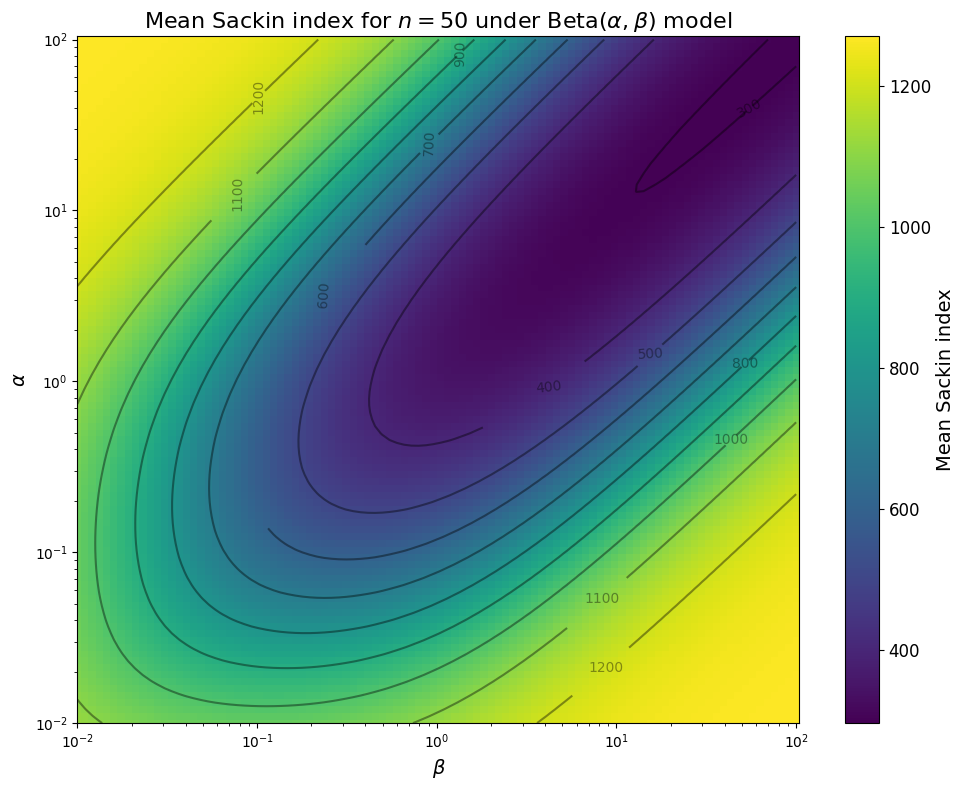

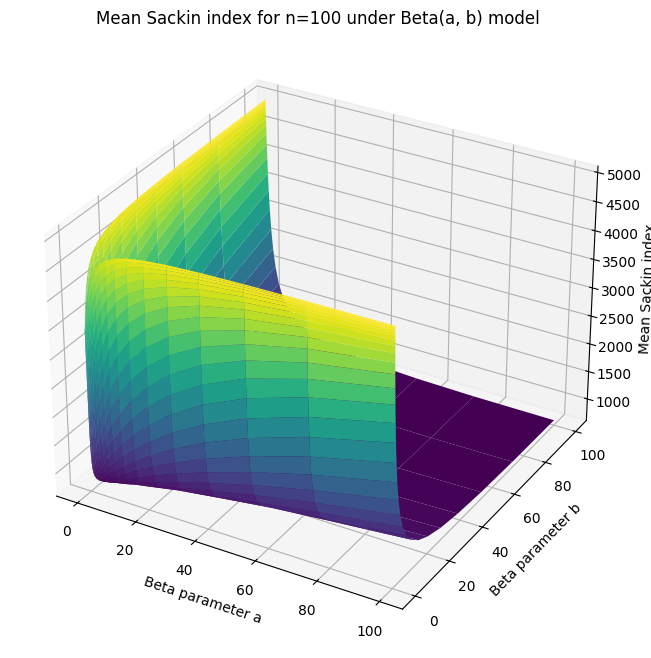

In [78]:
# Plot mean_sackin as a function of (a,b) in a 3D surface plot

from mpl_toolkits.mplot3d import Axes3D

plt.figure(figsize=(12, 8))
ax = plt.axes(projection='3d')
A, B = np.meshgrid(a, b)
ax.plot_surface(A, B, mean_sackin.T, cmap='viridis')
ax.set_xlabel('Beta parameter a')
ax.set_ylabel('Beta parameter b')
ax.set_zlabel('Mean Sackin index')
plt.title(f'Mean Sackin index for n={n} under Beta(a, b) model')
plt.show()

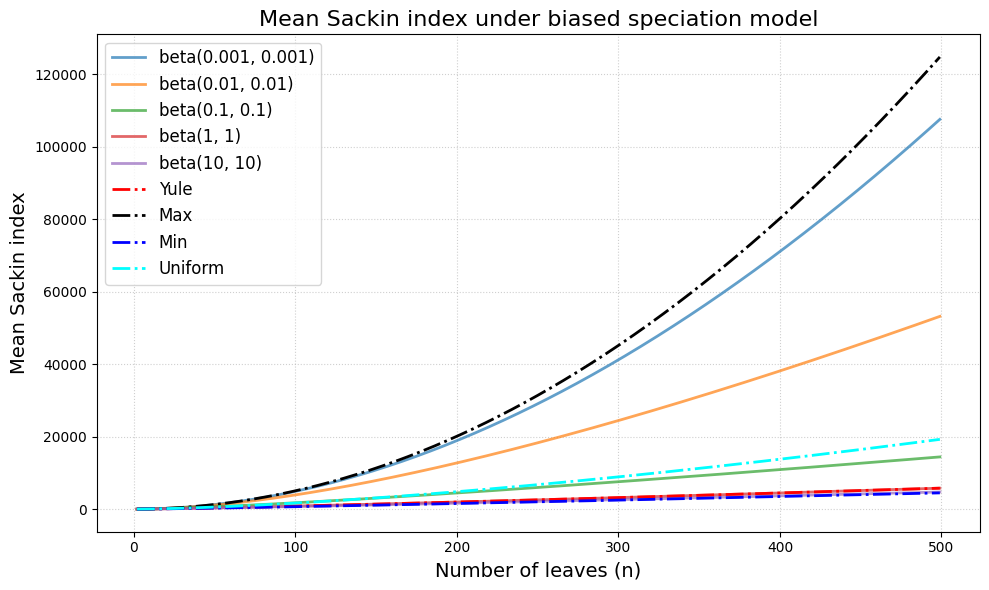

In [45]:
# Now make analogous plot for Beta(a,a) - Blum Francois model
a = [0.001, 0.01, 0.1, 1, 10]

N = np.arange(2, 500)

plt.figure(figsize=(10, 6))

colors = cm.viridis(np.linspace(0, 1, len(a)))

for (color, ai) in zip(colors, a):
    means = [sackin_mean_beta(n, ai, ai) for n in N]
    plt.plot(N, means, alpha=0.7, lw=2, label=f"beta({ai}, {ai})")

# Add reference models
plt.plot(N, [sackin_yule(n) for n in N], 
         label="Yule", linestyle='-.', color='red', linewidth=2)
plt.plot(N, [max_sackin(n) for n in N], 
         label="Max", linestyle='-.', color='black', linewidth=2)
plt.plot(N, [min_sackin(n) for n in N], 
         label="Min", linestyle='-.', color='blue', linewidth=2)
plt.plot(N, [sackin_uniform(n) for n in N], 
         label="Uniform", linestyle='-.', color='aqua', linewidth=2)

# Labels and title
plt.xlabel("Number of leaves (n)", fontsize=14)
plt.ylabel("Mean Sackin index", fontsize=14)
plt.title("Mean Sackin index under biased speciation model", fontsize=16)
plt.legend(fontsize=12, loc="upper left")


# Grid and layout

plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

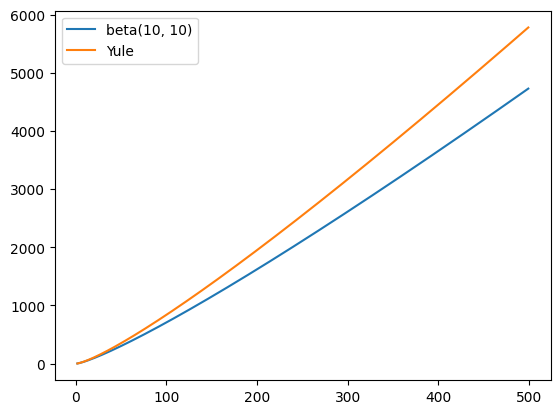

In [47]:
plt.plot(N, means, label=f"beta({ai}, {ai})")
plt.plot(N, [sackin_yule(n) for n in N], label="Yule")
plt.legend()
plt.show()

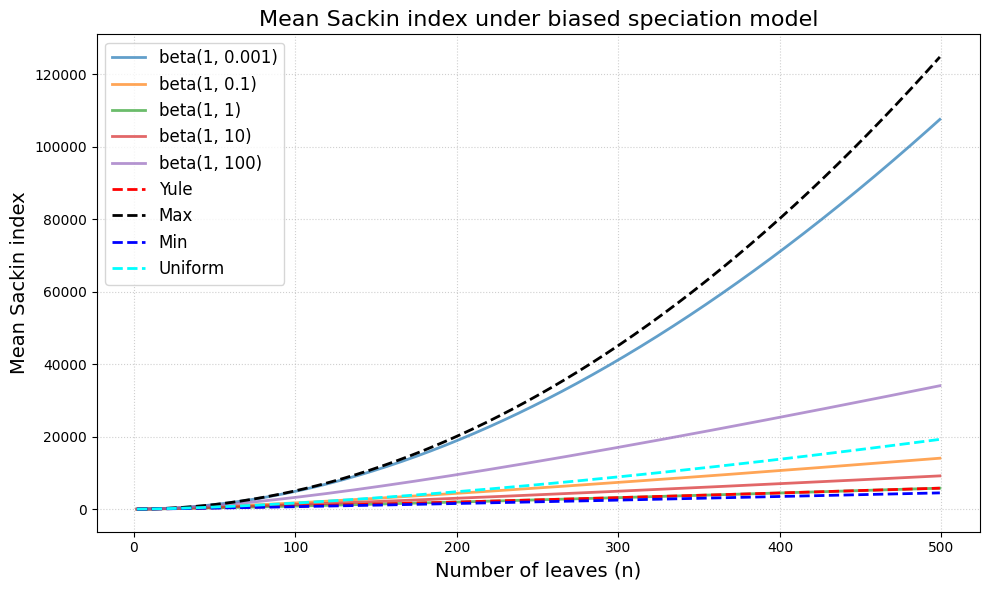

In [48]:
a = 1
b = [0.001, 0.1, 1, 10, 100]

plt.figure(figsize=(10, 6))

for bi in b:
    means = [sackin_mean_beta(n, a, bi) for n in N]
    plt.plot(N, means, alpha=0.7, lw=2, label=f"beta({a}, {bi})")
# Add reference models
plt.plot(N, [sackin_yule(n) for n in N], linestyle='dashed', color='red', label="Yule", linewidth=2)
plt.plot(N, [max_sackin(n) for n in N], linestyle='dashed', color='black', label="Max", linewidth=2)
plt.plot(N, [min_sackin(n) for n in N], linestyle='dashed', color='blue', label="Min", linewidth=2)
plt.plot(N, [sackin_uniform(n) for n in N], linestyle='dashed', color='aqua', label="Uniform", linewidth=2)

# Labels and title
plt.xlabel("Number of leaves (n)", fontsize=14)
plt.ylabel("Mean Sackin index", fontsize=14)
plt.title("Mean Sackin index under biased speciation model", fontsize=16)
plt.legend(fontsize=12, loc="upper left")
# Grid and layout
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()